# Creating Wind Shear Graphics

We will attempt to get the relevant graphs for Hurricanes Isabel and Matthew, as well as Typhoon Bolaven here!

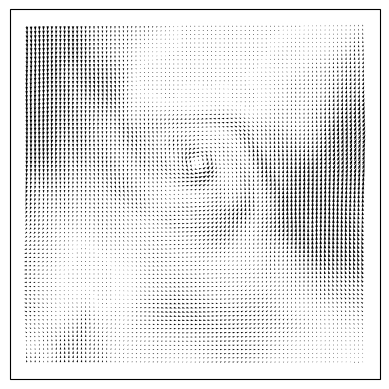

In [47]:
import matplotlib.pyplot as plt  # plotting library
import numpy as np  # numerical library
import xarray as xr  # netCDF library
import cartopy  # Map projections libary
import cartopy.crs as ccrs  # Projections list 

vws = xr.open_dataset(r'/Users/juliencheung/Documents/GitHub/Y1CyclonesSummerProject/data/isabelvws.nc') #peak intensity file, we should aim for a strengthening, peak, then weakening image for each cyclone.

# get u, v components at relevant pressures

u200 = vws.u.sel(valid_time="2003-09-11T18:00:00", pressure_level="200.0", method='nearest').load()
v200 = vws.v.sel(valid_time="2003-09-11T18:00:00", pressure_level="200.0", method='nearest').load()
u850 = vws.u.sel(valid_time="2003-09-11T18:00:00", pressure_level="850.0", method='nearest').load()
v850 = vws.v.sel(valid_time="2003-09-11T18:00:00", pressure_level="850.0", method='nearest').load()

u_vws = u850-u200
v_vws = v850-v200

magn = np.sqrt(u_vws**2 + v_vws**2)

ax = plt.axes(projection=ccrs.PlateCarree())
qv = ax.quiver(u_vws.longitude, u_vws.latitude, u_vws, v_vws, transform=ccrs.PlateCarree())



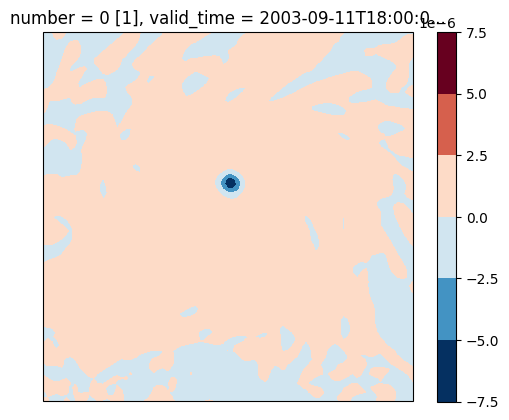

In [43]:
# testing out horizontal wind shear calculations, done by taking the difference between two contours in the x- and y- directions (take both the arrays!)
# we note that ERA5 has .25 degree measurements meaning that our horizontal shear data will be quite inaccuratev (come up with geographical distance interpretation of this later)
# horizontal shear equations adapted from https://math.stackexchange.com/questions/1196427/what-does-shear-mean 
# we take the horizontal difference at the 850hPa level!

# create horizontal matrix, divide by relative distances

dudy = u850.differentiate("latitude")/27830
dvdx = v850.differentiate("longitude")/(27830*np.cos(21.5))
dvdy = v850.differentiate("latitude")/27830
dudx = u850.differentiate("longitude")/(27830*np.cos(21.5))

det = dudx * dvdy - dvdx * dudy
ax = plt.axes(projection=ccrs.PlateCarree())
det.plot.contourf()

# need to find a means to create a potential function!))